In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Тикеры компаний из разных секторов
tickers = ['NVDA', 'GS', 'PFE', 'XOM', 'KO']

# Загружаем данные за 5 лет
print("Загружаем данные...")
data = yf.download(tickers, start='2020-01-01', end='2025-07-01')

# Сохраняем в CSV
data.to_csv('../data/stock_data.csv')
print("Данные сохранены в ../data/stock_data.csv")

# Смотрим, что получилось
print("\nПервые 5 строк:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

# Словарь для подписей графиков
companies = {'GS' : 'Sachs Group Inc.', 'KO': 'Coca-Cola Company', 'NVDA' : 'NVIDIA Corp.', 'PFE' : 'Pfizer Inc.', 'XOM' : 'ExxonMobil Holdings'}

Загружаем данные...


[*********************100%***********************]  5 of 5 completed

Данные сохранены в ../data/stock_data.csv

Первые 5 строк:
Price            Close                                                   High  \
Ticker              GS         KO      NVDA        PFE        XOM          GS   
Date                                                                            
2020-01-02  202.118896  45.141266  5.963804  27.048359  52.947029  202.394914   
2020-01-03  199.755463  44.894997  5.868346  26.903240  52.521370  200.643915   
2020-01-06  201.799744  44.878582  5.892958  26.868692  52.924633  201.860130   
2020-01-07  203.128113  44.533794  5.964302  26.778849  52.491497  205.094786   
2020-01-08  205.086151  44.615891  5.975488  26.993076  51.699905  206.802683   

Price                                                  ...        Open  \
Ticker             KO      NVDA        PFE        XOM  ...          GS   
Date                                                   ...               
2020-01-02  45.502461  5.963804  27.193483  53.036640  ...  199.255137

In [2]:
# 1. Изучение данных

# общая информация
print(data.info())

#количество дней промежутка
print(f'Диапазон: c {data.index[-1]} по {data.index[0]}, продолжительность: {data.index[-1] - data.index[0]}')

#количество Nanов
print('Количество Nan в каждом столбце:', data.isnull().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 1380 entries, 2020-01-02 to 2025-06-30
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GS)     1380 non-null   float64
 1   (Close, KO)     1380 non-null   float64
 2   (Close, NVDA)   1380 non-null   float64
 3   (Close, PFE)    1380 non-null   float64
 4   (Close, XOM)    1380 non-null   float64
 5   (High, GS)      1380 non-null   float64
 6   (High, KO)      1380 non-null   float64
 7   (High, NVDA)    1380 non-null   float64
 8   (High, PFE)     1380 non-null   float64
 9   (High, XOM)     1380 non-null   float64
 10  (Low, GS)       1380 non-null   float64
 11  (Low, KO)       1380 non-null   float64
 12  (Low, NVDA)     1380 non-null   float64
 13  (Low, PFE)      1380 non-null   float64
 14  (Low, XOM)      1380 non-null   float64
 15  (Open, GS)      1380 non-null   float64
 16  (Open, KO)      1380 non-null   float64
 17  (Open, NVDA)    1380 non-n

## Изучение данных
### Размеры:
    - 1380 строк
    - 25 колонок - 5 метрик на 5 компаний
### Метрики: 
    - Close - стоимость последней сделки с активом 
    - High - самая высокая актива цена за период времени
    - Low - самая низкая актива цена за период времени
    - Open - стоимость первой сделки с активом 
    - Volume - общее количество проданных и купленных активов за время формирования одной свечи
### Выбранный период времени:
    - 2020.01.02 - 2025.06.30 включительно, 2006 дней считая не рабочие
Пропущенных значений нет

In [4]:
# 2. Извлечение и визуализация цен закрытия
close_prices = data['Close']
close_prices

Ticker,GS,KO,NVDA,PFE,XOM
Date,,,,,
2020-01-02,202.118896,45.141266,5.963804,27.048359,52.947029
2020-01-03,199.755463,44.894997,5.868346,26.903240,52.521370
2020-01-06,201.799744,44.878582,5.892958,26.868692,52.924633
2020-01-07,203.128113,44.533794,5.964302,26.778849,52.491497
2020-01-08,205.086151,44.615891,5.975488,26.993076,51.699905
...,...,...,...,...,...
2025-06-24,651.904846,68.276367,147.703262,22.722149,104.993202
2025-06-25,659.545227,67.712326,154.104752,22.675415,105.022293
2025-06-26,676.568726,67.556747,154.813797,22.656721,106.592239


In [10]:
# 3-4. Расчёт доходности и её статистический анализ

# Также визуализировал

# Доходность
returns = close_prices.pct_change()

# Средняя доходность
mean_returns = returns.mean()

# Среднее отклонение доходности
std_returns = returns.std()

# Минимальная и максимальная дневная доходность
min_returns = returns.min()
max_returns = returns.max()

# Суммарная доходность за весь период
total_returns = (returns + 1).prod()

print("Средняя: ", mean_returns)
print("Отклонение: ", std_returns)
print("Минимальная: ", min_returns)
print("Максимальная: ", max_returns)
print("Суммарная: ", total_returns)

Средняя:  Ticker
GS      0.001121
KO      0.000391
NVDA    0.002967
PFE     0.000019
XOM     0.000720
dtype: float64
Отклонение:  Ticker
GS      0.021151
KO      0.013051
NVDA    0.034464
PFE     0.017174
XOM     0.021316
dtype: float64
Минимальная:  Ticker
GS     -0.127053
KO     -0.096725
NVDA   -0.184521
PFE    -0.077346
XOM    -0.122248
dtype: float64
Максимальная:  Ticker
GS      0.175803
KO      0.064796
NVDA    0.243696
PFE     0.108552
XOM     0.126868
dtype: float64
Суммарная:  Ticker
GS       3.447681
KO       1.524137
NVDA    26.456244
PFE      0.837638
XOM      1.973102
dtype: float64


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

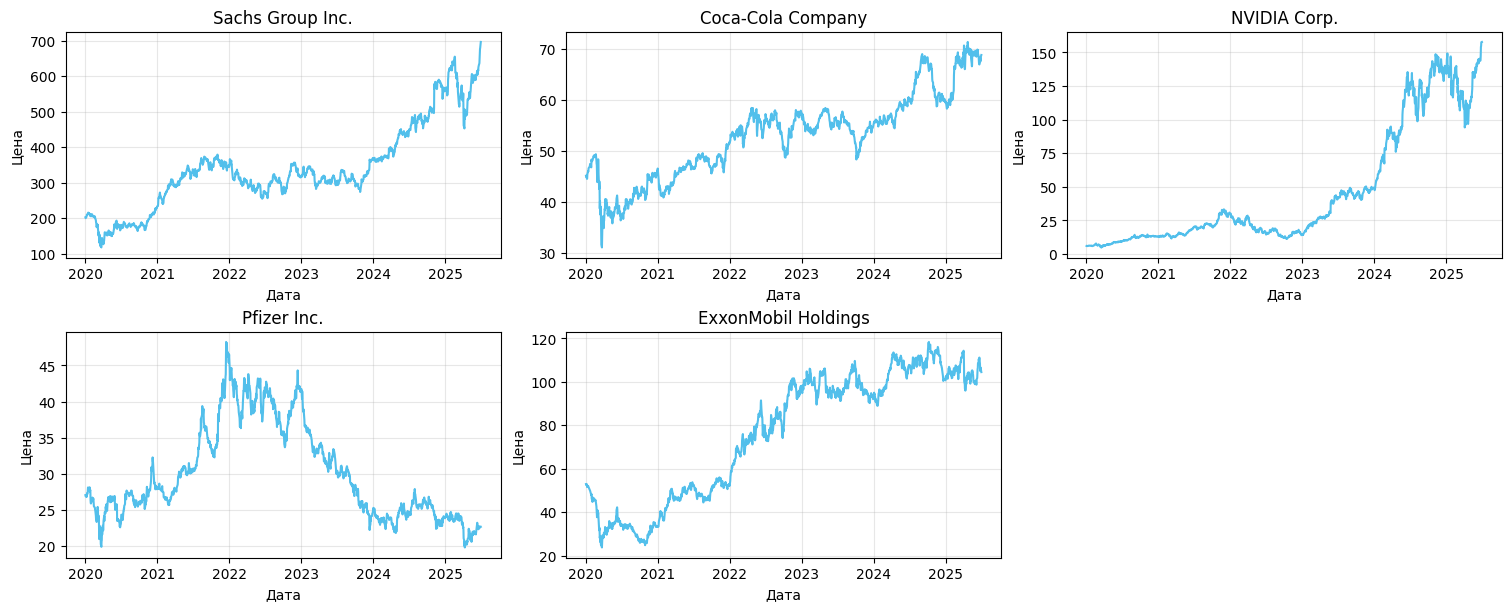

In [6]:
# 5. Визуализация цен (закрытия)

fig, axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")

for i in range(5):
    comp = close_prices.columns[i]
    axes[i//3, i%3].plot(close_prices[comp], color='#52bfeb')
    axes[i//3, i%3].set_title(companies[comp])
    axes[i//3, i%3].set_xlabel('Дата')
    axes[i//3, i%3].set_ylabel('Цена')
    axes[i//3, i%3].grid(True, alpha=0.3)
axes[1, 2].axis('off')

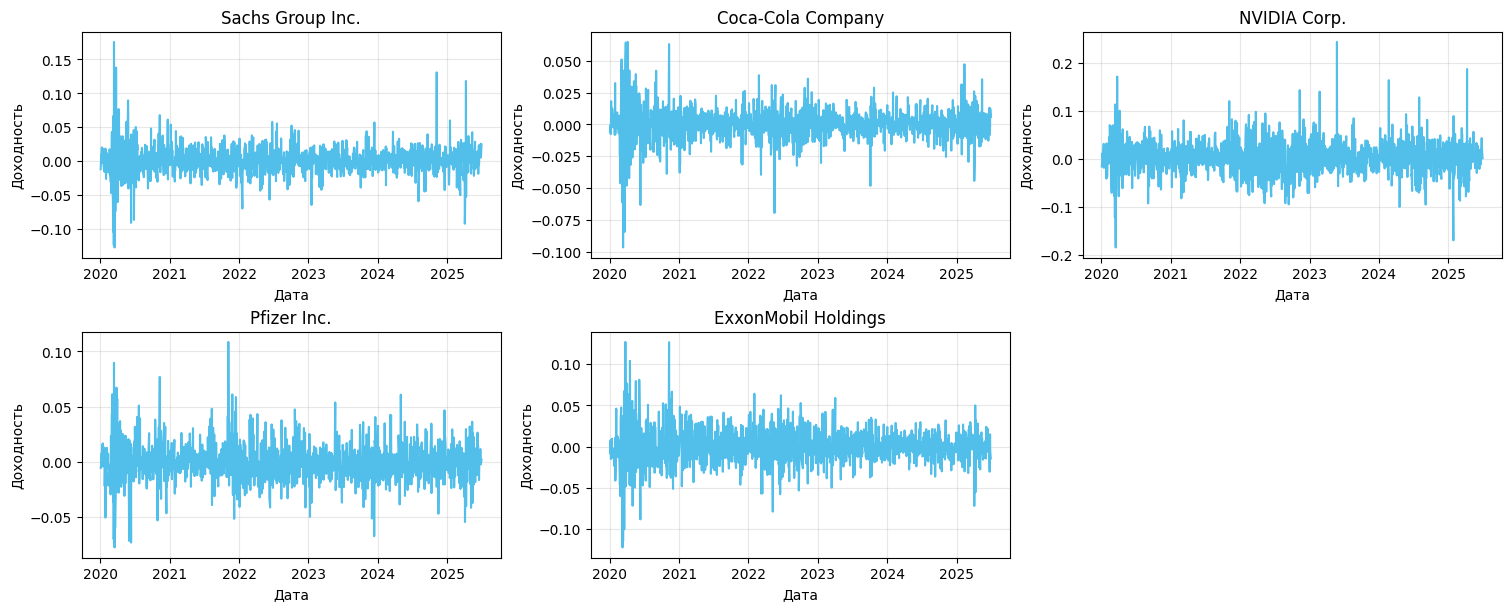

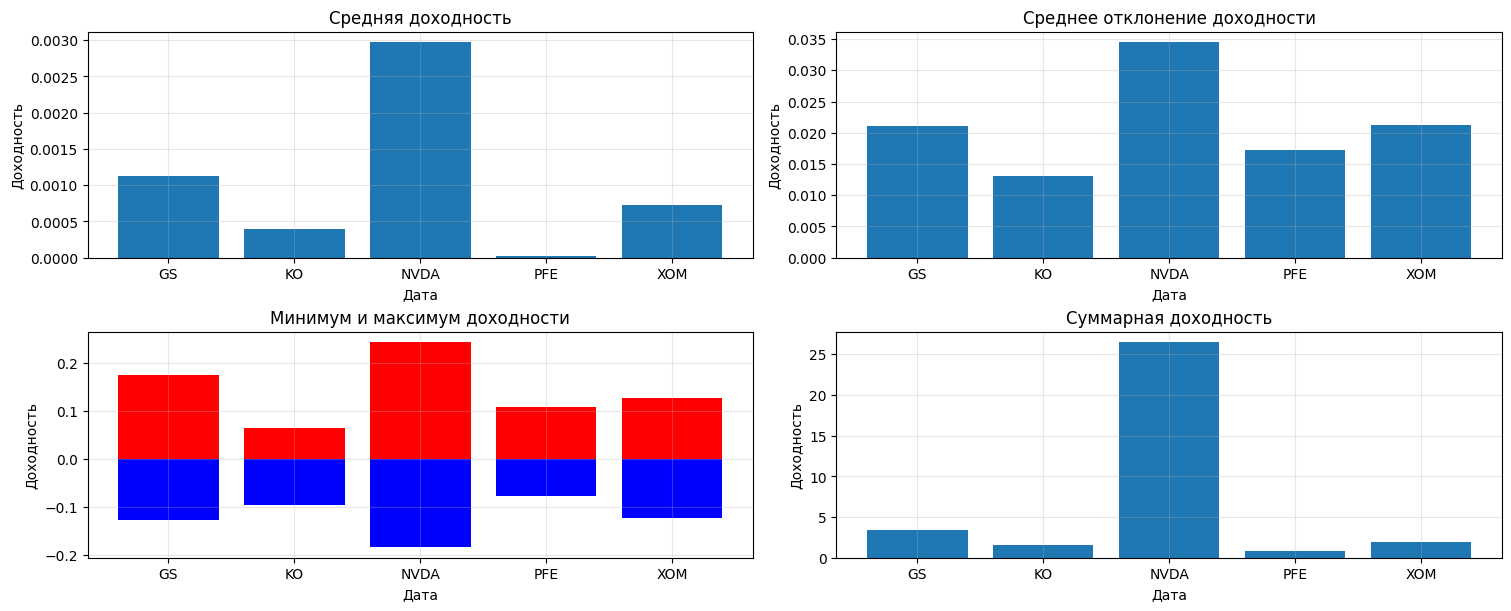

In [11]:
# 6. Визуализация доходности
prof_figure, prof_axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")
for i in range(5):
    comp = returns.columns[i]
    prof_axes[i//3, i%3].plot(returns[comp], color='#52bfeb')
    prof_axes[i//3, i%3].set_title(companies[comp])
    prof_axes[i//3, i%3].set_xlabel('Дата')
    prof_axes[i//3, i%3].set_ylabel('Доходность')
    prof_axes[i//3, i%3].grid(True, alpha=0.3)
prof_axes[1, 2].axis('off')

# Среднее
stat_figure, stat_axes = plt.subplots(2, 2, figsize=(15, 6), layout="constrained")
stat_axes[0, 0].bar(mean_returns.index, mean_returns)
stat_axes[0, 0].set_title('Средняя доходность')
stat_axes[0, 0].set_xlabel('Дата')
stat_axes[0, 0].set_ylabel('Доходность')
stat_axes[0, 0].grid(True, alpha=0.3)

# Отклонение
stat_axes[0, 1].bar(std_returns.index, std_returns)
stat_axes[0, 1].set_title('Среднее отклонение доходности')
stat_axes[0, 1].set_xlabel('Дата')
stat_axes[0, 1].set_ylabel('Доходность')
stat_axes[0, 1].grid(True, alpha=0.3)

# Минимум и максимум
stat_axes[1, 0].bar(max_returns.index, max_returns, color = 'red')
stat_axes[1, 0].bar(min_returns.index, min_returns, color = 'blue')
stat_axes[1, 0].set_title('Минимум и максимум доходности')
stat_axes[1, 0].set_xlabel('Дата')
stat_axes[1, 0].set_ylabel('Доходность')
stat_axes[1, 0].grid(True, alpha=0.3)

# Сумма
stat_axes[1, 1].bar(total_returns.index, total_returns)
stat_axes[1, 1].set_title('Суммарная доходность')
stat_axes[1, 1].set_xlabel('Дата')
stat_axes[1, 1].set_ylabel('Доходность')
stat_axes[1, 1].grid(True, alpha=0.3)


Минимальная корреляция 0.145 между компаниями NVDA, PFE
Максимальная корреляция 0.5353 между компаниями GS, XOM


<Axes: xlabel='Ticker', ylabel='Ticker'>

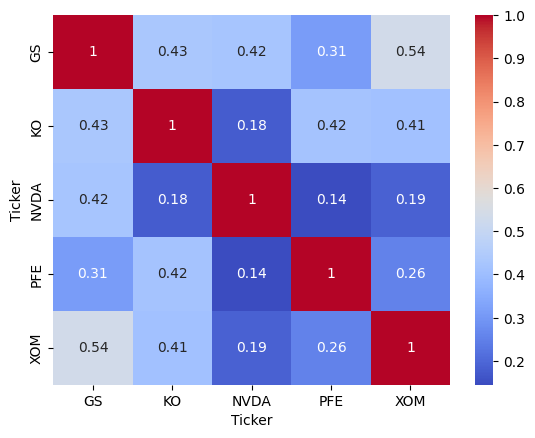

In [12]:
# 7. Корреляционный анализ

corr = returns.corr()
#corr.loc[corr.index == corr.columns] = np.nan
min_comp1 = corr.min().idxmin()
min_comp2 = corr.idxmin()[corr.min().idxmin()]
min_corr = round(corr.min().min(), 4)
max_comp1 = corr[corr < 1].max().idxmax()
max_comp2 = corr[corr < 1].idxmax()[corr[corr < 1].max().idxmax()]
max_corr = round(corr[corr < 1].max().max(), 4)

print(f'Минимальная корреляция {min_corr} между компаниями {min_comp1}, {min_comp2}')
print(f'Максимальная корреляция {max_corr} между компаниями {max_comp1}, {max_comp2}')
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

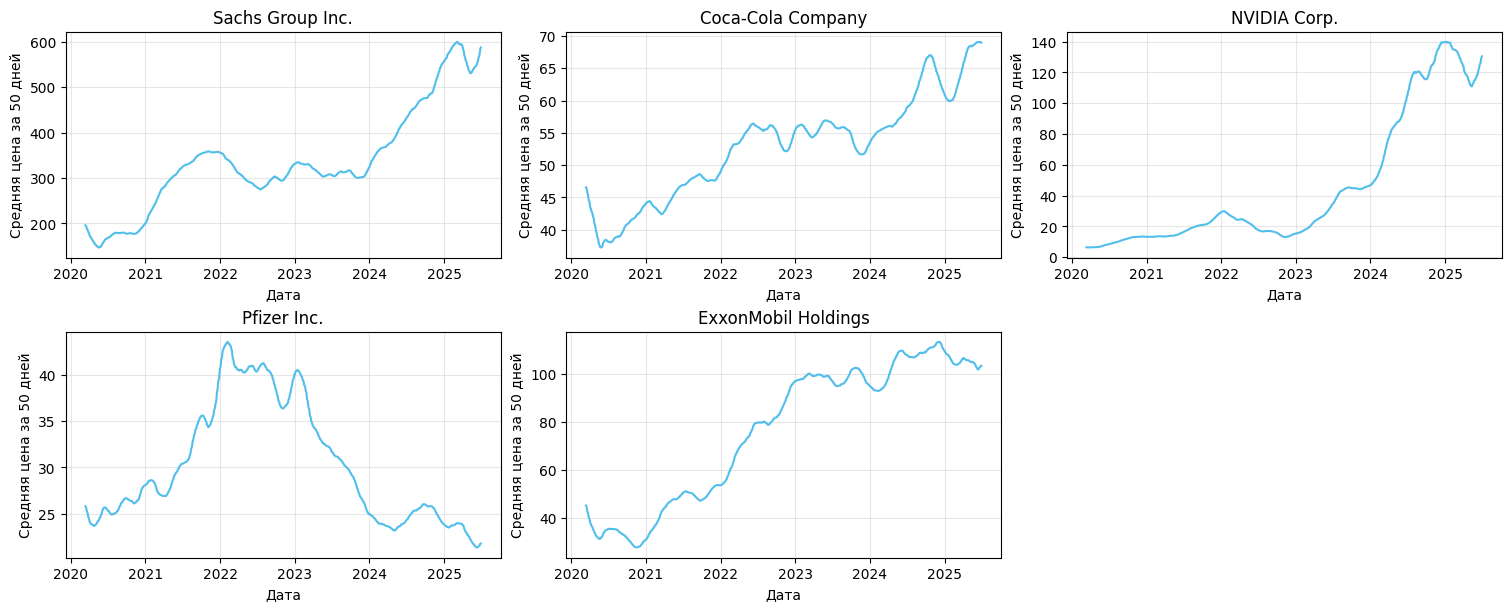

In [9]:
# 8 Скользящее среднее
sliding_mean = close_prices.rolling(window = 50).mean()

slid_figure, slid_axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")
for i in range(5):
    comp = sliding_mean.columns[i]
    slid_axes[i//3, i%3].plot(sliding_mean[comp], color='#52bfeb')
    slid_axes[i//3, i%3].set_title(companies[comp])
    slid_axes[i//3, i%3].set_xlabel('Дата')
    slid_axes[i//3, i%3].set_ylabel('Средняя цена за 50 дней')
    slid_axes[i//3, i%3].grid(True, alpha=0.3)
slid_axes[1, 2].axis('off')